In [1]:
! python3 -m pip install matplotlib
! python3 -m pip install qiskit qiskit-aer
import numpy as np
import matplotlib.pyplot as plt
from math import pi, gcd
from qiskit import *
from qiskit.circuit import *
from qiskit.circuit.library import *
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator, StatevectorSimulator
from scipy import optimize
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Small library for pretty-printing (nothing to do)

In [2]:
def nat2bl(pad,n):
    if n == 0: r = [0 for i in range(pad)]
    elif n % 2 == 1: r = nat2bl(pad-1,(n-1)//2); r.append(1)
    else: r = nat2bl(pad-1,n//2); r.append(0)
    return r

def bl2nat(s):
    if len(s) == 0: return 0
    else: a = s.pop(); return (a + 2*bl2nat(s))

def bl2bs(l):
    if len(l) == 0: return ""
    else: a = l.pop(); return (bl2bs(l) + str(a))

def nat2bs(pad,i): return bl2bs(nat2bl(pad,i))

def bs2bl(s):
    l = []
    for i in range(len(s)): l.append(int(s[i]))
    return l

def bs2nat(s): return bl2nat(bs2bl(s))


def processOneState(st): # Length = power of 2
        s = list(st)
        if len(s) == 2: return {'0' : s[0], '1' : s[1]}
        else:
            a0 = processOneState(s[:len(s)//2])
            a1 = processOneState(s[len(s)//2:])
            r = {}
            for k in a0: r['0' + k] = a0[k]
            for k in a1: r['1' + k] = a1[k]
            return r

def printOneState(d): # get a dict as per processStates output
    for k in d:
        im = d[k].imag
        re = d[k].real
        if abs(im) >= 0.001 or abs(re) >= 0.001:
            print("% .3f + % .3fj |%s>" % (re,im,k))

def printFinalRes(result):
    printOneState(processOneState(list(np.asarray(result))))

def runStateVector(qc):
    simulator = StatevectorSimulator()
    job = simulator.run(qc.decompose(reps=6), memory=True)
    job_result = job.result()
    result = job_result.results[0].to_dict()['data']['statevector']
    printFinalRes(result)

def runStateVectorSeveralTimes(qc, howmany):
    qc.save_statevector(label = 'collect', pershot = True)
    simulator = StatevectorSimulator()
    job = simulator.run(qc.decompose(reps=6), memory=True, shots=howmany)
    result = job.result()
    memory = result.data(0)['memory']
    collect = result.data(0)['collect']
    r = {}
    for i in range(len(collect)):
        r[str(collect[i])] = (0, collect[i])
    for i in range(len(collect)):
        n, v = r[str(collect[i])]
        r[str(collect[i])] = (n+1, v)
    for k in r:
        i, v = r[k]
        print(f"With {i} occurences:")
        printFinalRes(v)

def plotDistrib(d):
    sorted_items = sorted(d.items())
    keys = [k for k, _ in sorted_items]
    values = [v for _, v in sorted_items]
    plt.figure()
    plt.bar(keys, values)
    plt.xticks(rotation=90)
    plt.show()

def getSample(qc,howmany):
    simulator = AerSimulator()
    job = simulator.run(qc.decompose(reps=6), shots=howmany)
    res = dict(job.result().get_counts(qc))
    return res

def plotSample(qc,howmany):
    d = getSample(qc,howmany)
    ld = len(list(d.keys())[0])
    for i in range(2 ** ld):
        s = nat2bs(ld,i)
        if s not in d: d[s] = 0
    plotDistrib(d)

0 - Before anything else
Make sure you checked the notebook Qcomp-TP-0-Intro-QisKit
1 - Small practice
To start, build an entangled state of the form

1
√
2
(
|
00
⋯
0
⟩
+
|
11
⋯
1
⟩
)

over 
n
 qubits.

# Generating the circuit

In [3]:
def entangledState(n):
    q = QuantumRegister(n, name="q")   # We need n qubits...
    c = ClassicalRegister(n, name="c") # ... and n bits to store the results of the measurement later on
    qc = QuantumCircuit(q,c) # the circuit !
    
    # TODO : realize the circ that build 1/sqrt(2)(|00...0>+|11...1>)
    # TODO : (do not add any measurement)
    # TODO : check TP-Intro-QisKit to get how to do it !
    
    qc.h(0)
    for i in range(1,n):
        qc.cx(0,i)
    
    return qc

entangledState(4).draw()

┌───┐               
q_0: ┤ H ├──■────■────■──
     └───┘┌─┴─┐  │    │  
q_1: ─────┤ X ├──┼────┼──
          └───┘┌─┴─┐  │  
q_2: ──────────┤ X ├──┼──
               └───┘┌─┴─┐
q_3: ───────────────┤ X ├
                    └───┘
c: 4/════════════════════

In [4]:
# This prints the resulting state for various n

print("2 qubits")
runStateVector(entangledState(2))

print("4 qubits")
runStateVector(entangledState(4))

print("8 qubits")
runStateVector(entangledState(8))

print("16 qubits")
runStateVector(entangledState(16))

2 qubits
 0.707 +  0.000j |00>
 0.707 +  0.000j |11>
4 qubits
 0.707 +  0.000j |0000>
 0.707 +  0.000j |1111>
8 qubits
 0.707 +  0.000j |00000000>
 0.707 +  0.000j |11111111>
16 qubits
 0.707 +  0.000j |0000000000000000>
 0.707 +  0.000j |1111111111111111>


In [5]:
# This adds a measurement at the end and performs 1000 runs

qc = entangledState(5)

# this recovers the registers added to the circuit:
q = qc.qregs[0] 
c = qc.cregs[0]

qc.measure(q,c) # add a measure

getSample(qc,1000) # sample the circuit!

# TODO : Can you explain what you see?

{'00000': 491, '11111': 509}

{'00000': 505, '11111': 495}

2 - QPE
We've seen the QPE algorithm in the course, and we checked how it works with 3 qubits. Here we are going to implement it with the following unitary:

U = UnitaryGate(
    Operator([[1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,np.exp(pi*2j*(6/8))]]), label="U")

Questions
Q 2.1 Math questions
What is doing this operator ? (2j is in Python the complex number 
2
⋅
i
)
On how many qubits does it act ?
What are its eigenvalues/eigenvectors ?
For each eigenvector, what should QPE return with 3 bits of precisions, as seen in the course ?

Q 2.2 Implementing QPE
Below a template to fill in for

realizing QPE with size_eig bits of precision.
on the eigenvector of non-trivial eigenvalue
We initialized a quantum circuit with 3 registers:

eig for storing the eigenvalues
phi for storing the eigenvector
ceig for storing the result of the measurement of the eigenvalue-register.
the size of eig (and ceig) is a parameter, by default set to 3.
the size of phi is fixed, as it depends on U
Note that we only need to measure the eigenvalues!

What you will need:

QFTGate(size) build for you a QFT on size qubits.
U.control() for controlling a gate U. The control qubit should be placed first in the list of wires.
U.inverse() for the inverse of the gate U.
U.power(p) add p times U on the circuit.
qc.append(U, list_of_qubits) applies the gate U on the list of qubits.
Beware : phi (for instance) is not a list but a register. So if you want to concatenate it with something else, you first have to make a list out of it with list(phi).

In [6]:
U = UnitaryGate(
    Operator([[1,0,0,0],
              [0,1,0,0],
              [0,0,1,0],
              [0,0,0,np.exp(pi*2j*(6/8))]]), label="U")

In [7]:
def QPE(U, size_eig=3, endMeasure=False):
    size_phi = 2
    eig = QuantumRegister(size_eig, name="eig")
    phi = QuantumRegister(size_phi, name="phi")
    ceig = ClassicalRegister(size_eig, name="ceig")
    qc = QuantumCircuit(eig, phi ,ceig)
    
    qc.h(eig)
    
    qc.x(phi)

    qc.append(U.control(), [eig[0]] + list(phi))
    for i in range(1,size_eig):
        qc.append(U.power(2 ** i).control(),[eig[i]] + list(phi))
    
    qc.barrier()
    qc.append(QFTGate(size_eig).inverse(),eig)
    qc.barrier()

    # At the end, we possibly measure if the bit `endMeasure` was set
    if endMeasure:
        qc.measure(eig,ceig)
    
    return qc

In [8]:
# First, make sure that the drawing is OK.

QPE(U, size_eig=3).draw()

┌───┐                                   ░ ┌─────────┐ ░ 
 eig_0: ┤ H ├──■────────────────────────────────░─┤0        ├─░─
        ├───┤  │                                ░ │         │ ░ 
 eig_1: ┤ H ├──┼─────────■──────────────────────░─┤1 qft_dg ├─░─
        ├───┤  │         │                      ░ │         │ ░ 
 eig_2: ┤ H ├──┼─────────┼─────────────■────────░─┤2        ├─░─
        ├───┤┌─┴──┐┌─────┴──────┐┌─────┴──────┐ ░ └─────────┘ ░ 
 phi_0: ┤ X ├┤0   ├┤0           ├┤0           ├─░─────────────░─
        ├───┤│  U ││  unitary^2 ││  unitary^4 │ ░             ░ 
 phi_1: ┤ X ├┤1   ├┤1           ├┤1           ├─░─────────────░─
        └───┘└────┘└────────────┘└────────────┘ ░             ░ 
ceig: 3/════════════════════════════════════════════════════════

The resulting state vector is
 1.000 +  0.000j |11110>

Measuring 'eig' yields the probabilistic distribution
{'110': 1000}


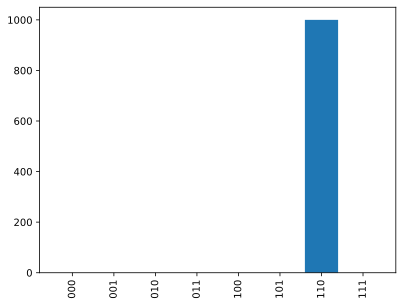

In [9]:
# Then run the backend, and check that the results are as expected

print("The resulting state vector is")

runStateVector(QPE(U, size_eig=3))

print()
print("Measuring 'eig' yields the probabilistic distribution")

print(getSample(QPE(U, size_eig=3,endMeasure=True), 1000))

plotSample(QPE(U, size_eig=3,endMeasure=True), 1000)

The resulting state vector is
 1.000 +  0.000j |11110>

Measuring 'eig' yields the probabilistic distribution
{'110': 1000}

Q 2.3 Exact result
(a) Is it the expected result ?
(b) Change the ordering of the wires of QFT
−
1
 by plugging it upside down: what do you see?
(b) Change the 
6
8
 of the phase of 
U
: use 
1
8
, then 
2
8
... Is QPE returning the correct answer?
(c) Change the precision : use 
4
 qubits for eig, and change the fraction in the phase of 
U
 to 
10
16
 : is QPE indeed returning 
10
 in binary ?
(d) Move to 
5
 bits of précision: is it still working ?

In [10]:
def U(frac):
    return UnitaryGate(
        Operator([[1,0,0,0],
                  [0,1,0,0],
                  [0,0,1,0],
                  [0,0,0,np.exp(pi*2j*frac)]]), label="U")

for i in range(8):
    print(f"The fraction in the phase is now {i}/8, with 5 bits we get the result")
    print(getSample(QPE(U(i/8), size_eig=5, endMeasure=True), 1000))

The fraction in the phase is now 0/8, with 5 bits we get the result
{'00000': 1000}
The fraction in the phase is now 1/8, with 5 bits we get the result
{'00100': 1000}
The fraction in the phase is now 2/8, with 5 bits we get the result
{'01000': 1000}
The fraction in the phase is now 3/8, with 5 bits we get the result
{'01100': 1000}
The fraction in the phase is now 4/8, with 5 bits we get the result
{'10000': 1000}
The fraction in the phase is now 5/8, with 5 bits we get the result
{'10100': 1000}
The fraction in the phase is now 6/8, with 5 bits we get the result
{'11000': 1000}
The fraction in the phase is now 7/8, with 5 bits we get the result
{'11100': 1000}


The fraction in the phase is now 0/8, with 5 bits we get the result
{'00000': 1000}
The fraction in the phase is now 1/8, with 5 bits we get the result
{'00100': 1000}
The fraction in the phase is now 2/8, with 5 bits we get the result
{'01000': 1000}
The fraction in the phase is now 3/8, with 5 bits we get the result
{'01100': 1000}
The fraction in the phase is now 4/8, with 5 bits we get the result
{'10000': 1000}
The fraction in the phase is now 5/8, with 5 bits we get the result
{'10100': 1000}
The fraction in the phase is now 6/8, with 5 bits we get the result
{'11000': 1000}
The fraction in the phase is now 7/8, with 5 bits we get the result
{'11100': 1000}

Q 2.4 Approximate result
Use 
1
3
 in the phase of 
U
:

With 3 bits of precision
With 4 bits of precision
With 5 bits of precision
Question What do you observe? Can you explain it? What do you read?

Answer The highest peak is corresponds to the best approximation of 
1
/
3
 as a fraction over 
2
s
i
z
e
_
e
i
g

with 2 bits of precision


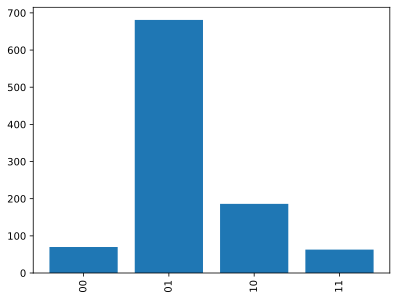

with 3 bits of precision


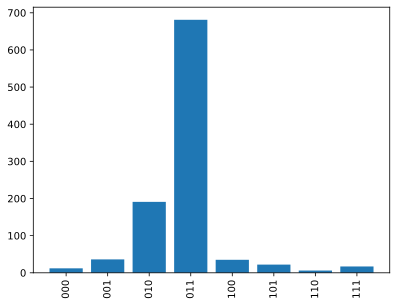

with 4 bits of precision


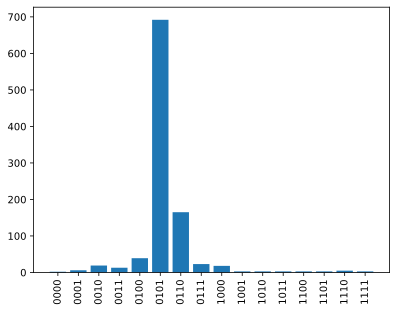

with 5 bits of precision


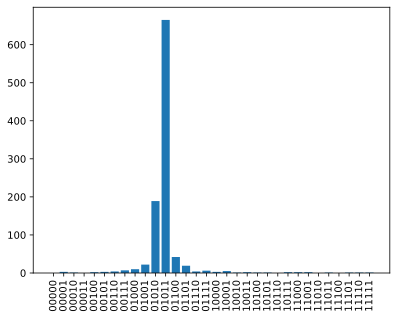

In [11]:
for i in range(2,6):
    print(f"with {i} bits of precision")
    plotSample(QPE(U(1/3), size_eig=i,endMeasure=True), 1000)

Q 2.5 Superposition
We saw that the circuit of QPE has no problem with a superposition of eigenvectors. Try to change the initialization of phi with
1
√
2
(
|
ϕ
1
⟩
+
|
ϕ
2
⟩
)
,
two eigenvectors of 
U
 (one with trivial eigenvalue, the other one non-trivial).

Also measure the register phi at the end of the circuit, and analyze the result: can you explain what you see? (Try this experiment with phase 
3
8
 and 
1
3
).

In [12]:
def QPEotherPhi(U, size_eig=3, endMeasure=False):
    size_phi = 2
    eig = QuantumRegister(size_eig, name="eig")
    phi = QuantumRegister(size_phi, name="phi")
    ceig = ClassicalRegister(size_eig, name="ceig")
    qc = QuantumCircuit(eig, phi ,ceig)
    
    qc.h(eig)
    
    qc.h(phi[0])
    qc.cx(phi[0],phi[1])
    
    qc.append(U.control(), [eig[0]] + list(phi))
    for i in range(1,size_eig):
        qc.append(U.power(2 ** i).control(),[eig[i]] + list(phi))
    
    qc.barrier()
    qc.append(QFTGate(size_eig).inverse(),eig)
    qc.barrier()
    
    if endMeasure:
        qc.measure(eig,ceig)
    
    return qc

with 2 bits of precision


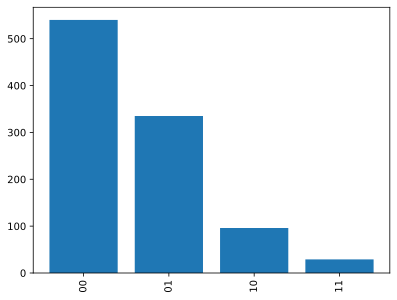

with 3 bits of precision


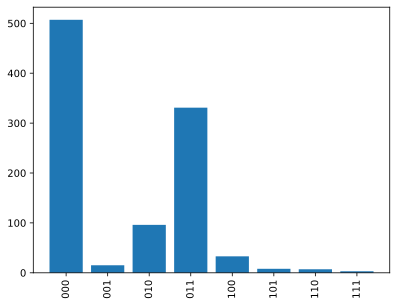

with 4 bits of precision


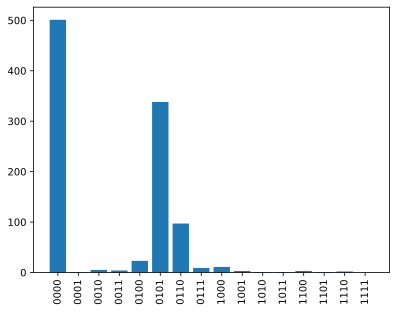

with 5 bits of precision


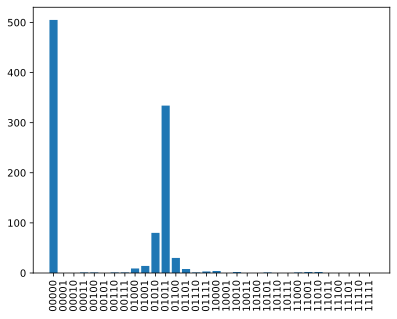

In [13]:
for i in range(2,6):
    print(f"with {i} bits of precision")
    plotSample(QPEotherPhi(U(1/3), size_eig=i,endMeasure=True), 1000)

Superposition (followed)
In the above case, the peak for 000..0 is strict. One can get two fuzzy peak if neither of the eigenvaluess can be exactly written.

For instance, consider the following

In [14]:
def V(frac1, frac2):
    return UnitaryGate(
        Operator([[np.exp(pi*2j*frac1),0,0,0],
                  [0,1,0,0],
                  [0,0,1,0],
                  [0,0,0,np.exp(pi*2j*frac2)]]), label="U")

with 2 bits of precision


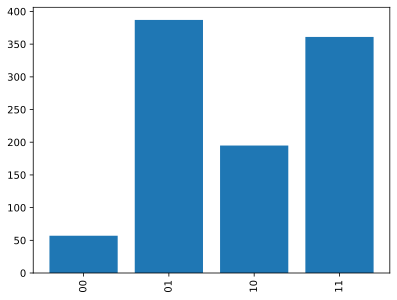

with 3 bits of precision


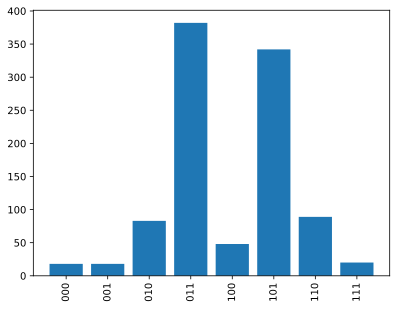

with 4 bits of precision


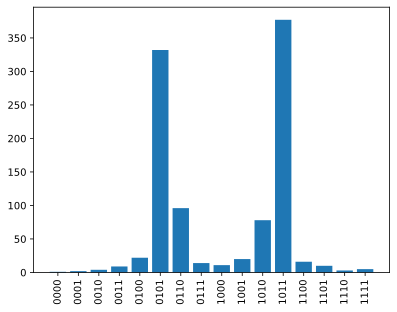

with 5 bits of precision


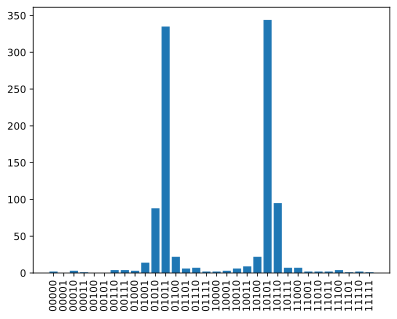

In [15]:
for i in range(2,6):
    print(f"with {i} bits of precision")
    plotSample(QPEotherPhi(V(1/3,2/3), size_eig=i,endMeasure=True), 1000)